# Descriptions vs. drawings (Bainbridge/Wilma 2019) - object counts

Compares how many **objects** people mention when they *describe* a ground-truth image with how
many objects they *drew* in the 2019 drawing study, across the same three memory tasks
(perception / immediate memory / delayed memory).

View 1 covers every feedback type (aigen / nogen / plain) plus the `gpt-5.5_desc` reference;
Views 2-5 drill into `aigen` alone.

- **descriptions** source: `<processed_dir>/nlp_analysis/trials_final_semantic_tags.csv` per
  condition; the `objects` column is a stringified list, its length is the count.
- **drawings** source: `Data/other_datasets/wilmas_drawings_2019/wilmas_data_2019.csv`
  (`category, condition, count`) - already-aggregated **means** (objects per drawing), one number
  per condition, so they carry no error bars here.
- **gpt-5.5_desc** source: `<combined>/gpt-5.5_desc/gpt-5.5_desc_semantic_tags_verbosity-medium.csv`,
  written by `analysis/gpt_image_desc_api.py` - GPT describing each GT image while looking at it.

**`COUNT_MODE` toggle (load cell below).** Same idea as `cross_gen_validated_semantic_counts.ipynb`:

- `"raw"` — object count = number of tagged objects, exactly as before.
- `"validated"` — every describing bar (aigen / nogen / plain, and the `gpt-5.5_desc` line) splits
  into the objects the judge confirmed are visible in the GT image (**solid**) and the objects it
  could not find (**hollow cap = hallucinations**), read from
  `<processed_dir>/nlp_analysis/trials_final_semantic_tag_image_validation.csv`. The 2019 drawings
  bar cannot be validated, so it is unchanged.

Flip `COUNT_MODE` in the first load cell and re-run; every view respects it.

**Caveat.** These are two different modalities from two different studies: an object *drawn*
and an object *named in a description* are not the same unit, and the drawing numbers are
group means we cannot re-derive spread for. Read the bars as a rough level comparison of how
much scene content survives each memory task, not as a like-for-like statistical test.

All views are **bar charts**, as requested.

In [1]:
import sys
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

# Find project root (the dir containing config.py) regardless of where the notebook sits.
project_root = Path.cwd()
while not (project_root / "config.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config
print("project root:", project_root)

project root: /mnt/hdd/anatkorol/Imagination_in_translation


In [2]:
# --- THE TOGGLE --------------------------------------------------------------
# "raw"       -> object count = len(objects list), as tagged (trials_final_semantic_tags.csv)
# "validated" -> each describing bar splits into objects the judge found in the GT image
#                (solid) and objects it could not find (hollow cap = hallucinations), read from
#                trials_final_semantic_tag_image_validation.csv. Drawings (2019) cannot be
#                validated and are unchanged; the gpt-5.5_desc line switches to its validated count.
COUNT_MODE = "validated"
assert COUNT_MODE in ("raw", "validated"), COUNT_MODE

SEM_FILE = "trials_final_semantic_tags.csv"
VAL_FILE = "trials_final_semantic_tag_image_validation.csv"
GEN = "aigen"


def _count(cell):
    """Length of a stringified list cell; 0 for empty / NaN / unparseable."""
    if pd.isna(cell):
        return 0
    try:
        val = ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        return 0
    return len(val) if isinstance(val, (list, tuple)) else 0


def load_generations(gens):
    """Load per-trial object counts for the given generation(s), honoring COUNT_MODE.

    Returns a long df with one row per trial and two count columns:
      n_objects -> the plotted object count (validated count in "validated" mode)
      h_objects -> hallucination cap: objects the judge could not find in the image
                   (0 throughout in "raw" mode)
    In "validated" mode rows the judge could not score (error set) are dropped.
    """
    fname = VAL_FILE if COUNT_MODE == "validated" else SEM_FILE
    frames, n_err = [], 0
    for g in gens:
        for c in config.GROUPS_BY_GEN[g]:
            p = config.paths_for(c).processed_dir / "nlp_analysis" / fname
            if not p.exists():
                print(f"skip {c}: {fname} not found ({p})")
                continue
            d = pd.read_csv(p)
            # Rows the judge could not score (API failure, missing image, ...) carry NaN counts.
            if COUNT_MODE == "validated" and "error" in d.columns and d["error"].notna().any():
                n_bad = int(d["error"].notna().sum())
                n_err += n_bad
                print(f"  !! {c}: dropping {n_bad}/{len(d)} row(s) with a validation error")
                d = d[d["error"].isna()].copy()
            cm = config.mapping_data["CONDITIONS"][c]
            d["condition"], d["generation"], d["task"] = c, cm["generation"], cm["task"]
            if COUNT_MODE == "validated":
                d["n_objects"] = pd.to_numeric(d["n_validated_objects"], errors="coerce")
                d["h_objects"] = pd.to_numeric(d["n_invalid_not_in_image_objects"], errors="coerce")
            else:
                d["n_objects"] = d["objects"].apply(_count)
                d["h_objects"] = 0
            frames.append(d)
            print(f"loaded {c}: {len(d)} rows, {d['uid'].nunique()} participants")
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if n_err:
        print(f"!! {n_err} row(s) dropped for validation errors - re-run the validator to recover them")
    return out


aigen = load_generations([GEN])
assert not aigen.empty, f"no data found for any {GEN} condition (mode={COUNT_MODE!r})"
aigen["attempt"] = aigen["attempt"].astype(int)
print(f"\nCOUNT_MODE = {COUNT_MODE!r}")
aigen.groupby(["task", "attempt"]).size().unstack("attempt")

loaded aigen_perc: 279 rows, 20 participants
loaded aigen_imm: 327 rows, 23 participants
loaded aigen_del: 297 rows, 23 participants

COUNT_MODE = 'validated'


attempt,1,2,3
task,,,
delay,99,99,99
immediate,109,109,109
perception,93,93,93


In [3]:
# --- drawings (2019) ---------------------------------------------------------
DRAWINGS_CSV = config.ROOT / "Data" / "other_datasets" / "wilmas_drawings_2019" / "wilmas_data_2019.csv"

# The drawings file names its conditions in prose; map them onto our task slugs.
DRAW_TASK = {"perception": "perception", "immediate memory": "immediate", "delayed memory": "delay"}

draw = pd.read_csv(DRAWINGS_CSV)
draw["condition"] = draw["condition"].str.strip().str.lower()
draw = draw[draw["category"].str.strip().str.lower() == "objects"].copy()
draw["task"] = draw["condition"].map(DRAW_TASK)
assert draw["task"].notna().all(), f"unmapped drawing conditions: {draw.loc[draw['task'].isna(), 'condition'].tolist()}"
draw = draw[["task", "count"]].rename(columns={"count": "drawn_objects"})
draw

,task,drawn_objects
0,perception,9.4
1,immediate,7.8
2,delay,7.0


In [4]:
# --- Style + fixed colors ----------------------------------------------------
sns.set_theme(style="whitegrid")

TASK_ORDER  = ["perception", "immediate", "delay"]
TASK_LABELS = {"perception": "Perception", "immediate": "Immediate memory", "delay": "Delayed memory"}
ATTEMPTS    = [1, 2, 3]

# aigen keeps its Dark2 green from the cross-generation notebooks; drawings get a neutral grey.
SRC_COLORS = {"aigen": "#1b9e77", "drawings": "#7f7f7f"}
SRC_LABELS = {"aigen": "AI-gen descriptions", "drawings": "Drawings (2019)"}
# Same green, light -> dark, one shade per attempt.
ATTEMPT_COLORS = {1: "#a6dbc8", 2: "#5cbb9c", 3: "#1b9e77"}

GRAPHS = (config.ROOT / "analysis" / "outputs" / config.DATASET / "combined" / "graphs"
          / "drawings_comparison")
GRAPHS.mkdir(parents=True, exist_ok=True)
print("saving figures to:", GRAPHS)

saving figures to: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/drawings_comparison


## View 1 - every feedback type vs the drawings, objects only
The headline comparison: **all** generations (aigen / nogen / plain) laid out the way
`cross_gen_semantic_counts.ipynb` View 1b does - one panel per task, x = attempt, one bar per
generation, participant means as dots - with the 2019 drawings as a fourth grey bar in each
panel and `gpt-5.5_desc` as the dashed line.

So one panel holds every reference point we have for the same ground-truth images: what people
*wrote* under each feedback type and attempt, what people *drew* in 2019, and what GPT writes
with the image in front of it. Views 2-5 below drill into `aigen` vs the drawings alone.

Same caveat as the top of this notebook, and one more: the drawings number is a published group
mean with no recoverable spread, so its bar is flat and carries no dots.

In [5]:
# --- Data for View 1: all generations + the gpt-5.5_desc objects value -------------------
# Cell 2 loaded aigen only; here we load every generation the same way, honoring COUNT_MODE.
all_gen = load_generations(["aigen", "nogen", "plain"])
all_gen["attempt"] = all_gen["attempt"].astype(int)
GEN_ORDER = [g for g in ["aigen", "nogen", "plain"] if g in set(all_gen["generation"])]

# gpt-5.5_desc: GPT describing each GT image while looking at it (analysis/gpt_image_desc_api.py).
# In "validated" mode we read its judged file so the line is comparable to the (validated) bars.
# Both modes accept the older "gpt_ceiling" folder name until that folder is renamed.
_gpt_dir = config.COMBINED_PROCESSED_DIR
if COUNT_MODE == "validated":
    _gpt_candidates = [
        _gpt_dir / "gpt-5.5_desc"
        / "gpt-5.5_desc_semantic_tag_image_validation_verbosity-medium.csv",
        _gpt_dir / "gpt_ceiling"
        / "gpt_ceiling_semantic_tag_image_validation_verbosity-medium.csv"]
else:
    _gpt_candidates = [
        _gpt_dir / "gpt-5.5_desc" / "gpt-5.5_desc_semantic_tags_verbosity-medium.csv",
        _gpt_dir / "gpt_ceiling" / "gpt_ceiling_semantic_tags_verbosity-medium.csv"]
_gpt_path = next((p for p in _gpt_candidates if p.exists()), None)
if _gpt_path is not None:
    _gpt = pd.read_csv(_gpt_path)
    if COUNT_MODE == "validated":
        if "error" in _gpt.columns:
            _gpt = _gpt[_gpt["error"].isna()].copy()
        GPT_DESC_OBJECTS = pd.to_numeric(_gpt["n_validated_objects"], errors="coerce").mean()
        GPT_DESC_OBJECTS_CAP = pd.to_numeric(_gpt["n_invalid_not_in_image_objects"],
                                             errors="coerce").mean()
    else:
        GPT_DESC_OBJECTS = _gpt["objects"].apply(_count).mean()
        GPT_DESC_OBJECTS_CAP = 0.0
    print(f"gpt-5.5_desc ({COUNT_MODE}): {GPT_DESC_OBJECTS:.2f} objects per image "
          f"({len(_gpt)} images)")
else:
    GPT_DESC_OBJECTS, GPT_DESC_OBJECTS_CAP = None, 0.0
    print(f"no gpt-5.5_desc file for mode {COUNT_MODE!r} - run analysis/gpt_image_desc_api.py"
          " (+ object_accuracy_detector.py -c gpt-5.5_desc for validated)")

GPT_DESC_COLOR, GPT_DESC_LABEL = "#444444", "gpt-5.5_desc"
GEN_COLORS = {"aigen": "#1b9e77", "nogen": "#d95f02", "plain": "#7570b3"}
GEN_LABELS = {"aigen": "AI-gen (image)", "nogen": "No-gen (text)", "plain": "Plain (baseline)"}
DRAW_COLOR, DRAW_LABEL = "#7f7f7f", "Drawings (2019)"

all_gen.groupby(["generation", "task"]).size().unstack("task")

loaded aigen_perc: 279 rows, 20 participants
loaded aigen_imm: 327 rows, 23 participants
loaded aigen_del: 297 rows, 23 participants
loaded nogen_perc: 237 rows, 17 participants
loaded nogen_imm: 288 rows, 21 participants
loaded nogen_del: 222 rows, 18 participants
loaded plain_perc: 121 rows, 25 participants
loaded plain_imm: 114 rows, 25 participants
loaded plain_del: 96 rows, 20 participants
gpt-5.5_desc (validated): 21.00 objects per image (5 images)


task,delay,immediate,perception
generation,,,
aigen,297,327,279
nogen,222,288,237
plain,96,114,121


saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/drawings_comparison/all_generations_vs_drawings_objects_validated.png


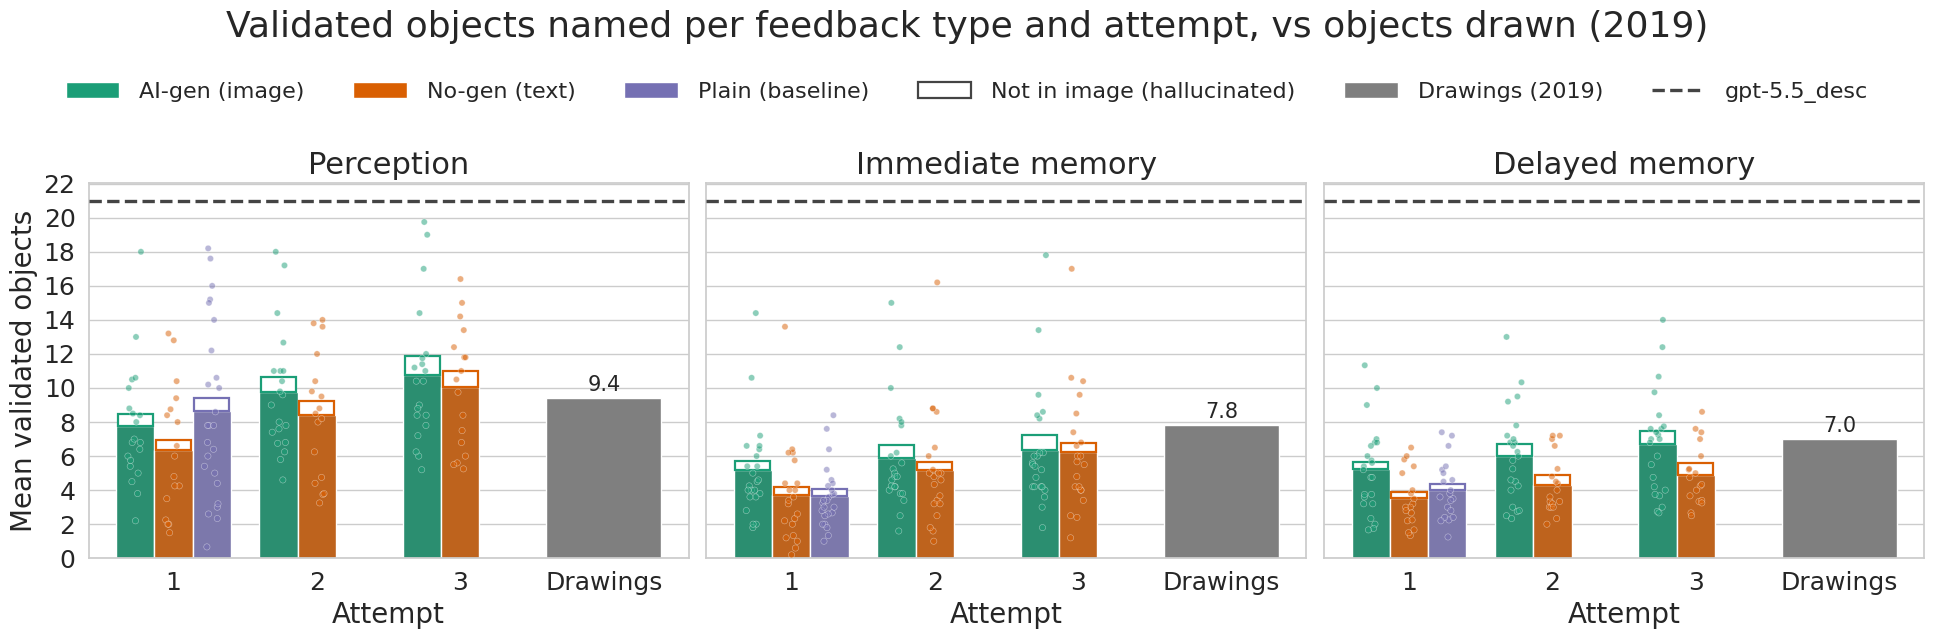

In [6]:
# --- View 1 plot: presentation styling, matching cross_gen_semantic_counts View 1b --------
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")

# Presentation-sized type, applied only to this figure (rc_context below) so the smaller
# views further down keep the default theme.
PRESENTATION_RC = {
    "axes.titlesize": 22, "axes.labelsize": 20, "xtick.labelsize": 18,
    "ytick.labelsize": 18, "legend.fontsize": 16, "figure.titlesize": 26,
}

# x slots: the three attempts, then the drawings as a fourth (they have no attempts).
DRAW_SLOT = "Drawings"
X_SLOTS = [str(a) for a in ATTEMPTS] + [DRAW_SLOT]

# Hollow-cap idiom, borrowed from cross_gen_validated_semantic_counts: the "not in image"
# segment is the SAME hue as its bar, hollow instead of solid - a part of that bar's total,
# not a new series, so it must not introduce a new color.
CAP_FACE, CAP_LW, CAP_LABEL = "white", 1.6, "Not in image (hallucinated)"


def _dodge(gens):
    """x offset and width of each dodged slot, matching seaborn's categorical dodge
    (total slot width 0.8 split evenly between the hue levels)."""
    n = len(gens)
    width = 0.8 / n
    return {g: (i - (n - 1) / 2) * width for i, g in enumerate(gens)}, width


def add_caps(ax, x_index, gens, bottoms, caps):
    """Stack the hollow 'not in image' segment on top of each dodged bar, using seaborn's
    own dodge geometry so caps land exactly on their bars."""
    offsets, width = _dodge(gens)
    for xv, i in x_index.items():
        for g in gens:
            h = caps.get((xv, g), 0)
            if not h or np.isnan(h):
                continue
            ax.bar(i + offsets[g], h, bottom=bottoms.get((xv, g), 0),
                   width=width * 0.92, facecolor=CAP_FACE, edgecolor=GEN_COLORS[g],
                   linewidth=CAP_LW, zorder=2.5)


def _all_gen_ppt_means():
    """Mean object count + hallucination cap per (generation, task, uid, attempt)."""
    return (all_gen.groupby(["generation", "task", "uid", "attempt"], as_index=False)
                   [["n_objects", "h_objects"]].mean()
                   .rename(columns={"n_objects": "count", "h_objects": "cap"}))


def plot_all_generations_vs_drawings(save=True):
    """One panel per task; bars = generation x attempt, plus the 2019 drawings bar and the
    gpt-5.5_desc line. Dots are individual participant means. In "validated" mode each
    describing bar carries a hollow 'not in image' cap on top."""
    g = _all_gen_ppt_means()
    g["slot"] = g["attempt"].astype(str)
    dvals = draw.set_index("task")["drawn_objects"]
    # Tallest thing a panel must fit: the highest per-participant dot, the tallest stacked
    # (validated + cap) bar, the drawings bar, or the gpt-5.5_desc line.
    stacked = (g.groupby(["task", "slot", "generation"])[["count", "cap"]].mean()
                .sum(axis=1).max()) if not g.empty else 0
    vmax = max(g["count"].max(), stacked, dvals.max(), GPT_DESC_OBJECTS or 0)

    with plt.rc_context(PRESENTATION_RC):
        fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(6.5 * len(TASK_ORDER), 6.5),
                                 sharey=True)
        axes = np.atleast_1d(axes)
        for i, (ax, task) in enumerate(zip(axes, TASK_ORDER)):
            sub = g[g["task"] == task]
            sns.barplot(data=sub, x="slot", y="count", hue="generation",
                        order=X_SLOTS, hue_order=GEN_ORDER, palette=GEN_COLORS,
                        errorbar=None, legend=False, ax=ax, zorder=2)
            # Hollow 'not in image' caps, stacked on each describing bar's mean height.
            if COUNT_MODE == "validated":
                means = sub.groupby(["slot", "generation"])[["count", "cap"]].mean()
                add_caps(ax, {s: k for k, s in enumerate(X_SLOTS)}, GEN_ORDER,
                         bottoms=means["count"].to_dict(), caps=means["cap"].to_dict())
            sns.stripplot(data=sub, x="slot", y="count", hue="generation",
                          order=X_SLOTS, hue_order=GEN_ORDER, palette=GEN_COLORS,
                          dodge=True, jitter=0.16, size=4.5, alpha=0.5, linewidth=0.4,
                          edgecolor="white", legend=False, ax=ax, zorder=3)
            # The drawings value fills the whole 4th slot (no attempts, no participants to dot).
            if task in dvals.index:
                ax.bar(len(ATTEMPTS), dvals[task], width=0.8, color=DRAW_COLOR, zorder=2)
                ax.text(len(ATTEMPTS), dvals[task] + vmax * 0.02, f"{dvals[task]:.1f}",
                        ha="center", fontsize=15)
            if GPT_DESC_OBJECTS is not None:
                ax.axhline(GPT_DESC_OBJECTS, color=GPT_DESC_COLOR, ls="--", lw=2.4, zorder=4)
            ax.set_title(TASK_LABELS[task])
            ax.set_xlabel("Attempt")
            ylab = "Mean validated objects" if COUNT_MODE == "validated" else "Mean number of objects"
            ax.set_ylabel(ylab if i == 0 else "")
            ax.set_ylim(bottom=0)
            ax.yaxis.set_major_locator(MultipleLocator(5 if vmax > 25 else 2))

        handles = [Patch(facecolor=GEN_COLORS[gen], label=GEN_LABELS[gen]) for gen in GEN_ORDER]
        if COUNT_MODE == "validated":
            handles.append(Patch(facecolor=CAP_FACE, edgecolor="#444444", linewidth=CAP_LW,
                                 label=CAP_LABEL))
        handles.append(Patch(facecolor=DRAW_COLOR, label=DRAW_LABEL))
        if GPT_DESC_OBJECTS is not None:
            handles.append(Line2D([], [], color=GPT_DESC_COLOR, lw=2.4, ls="--",
                                  label=GPT_DESC_LABEL))
        fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.90),
                   ncol=len(handles), frameon=False, columnspacing=2.2,
                   handlelength=2.4, handletextpad=0.9)
        kind = "validated objects" if COUNT_MODE == "validated" else "objects"
        fig.suptitle(f"{kind.capitalize()} named per feedback type and attempt, vs objects drawn (2019)")
        fig.tight_layout(rect=(0, 0, 1, 0.87))
        if save:
            out = GRAPHS / f"all_generations_vs_drawings_objects_{COUNT_MODE}.png"
            fig.savefig(out, dpi=300, bbox_inches="tight", pad_inches=0.35)
            print("saved:", out)
        plt.show()


plot_all_generations_vs_drawings()

In [ ]:
# --- Per-participant object counts (the unit for every aigen bar) ------------
def ppt_attempt_means():
    """Mean object count + hallucination cap per (task, uid, attempt), collapsing
    sessions / GT images. `count` is the validated count in "validated" mode; `cap` is the
    'not in image' count (0 in "raw" mode)."""
    return (aigen.groupby(["task", "uid", "attempt"], as_index=False)[["n_objects", "h_objects"]]
                 .mean().rename(columns={"n_objects": "count", "h_objects": "cap"}))


def ppt_means():
    """Mean object count + cap per (task, uid), collapsing attempts as well."""
    return (ppt_attempt_means().groupby(["task", "uid"], as_index=False)[["count", "cap"]].mean())


ppt = ppt_means()
summary = (ppt.groupby("task")["count"].agg(["mean", "sem", "count"])
              .reindex(TASK_ORDER)
              .join(draw.set_index("task")["drawn_objects"]))
if COUNT_MODE == "validated":
    summary["mean_hallucinated"] = ppt.groupby("task")["cap"].mean().reindex(TASK_ORDER)
summary["diff (aigen - drawings)"] = summary["mean"] - summary["drawn_objects"]
summary.rename(columns={"count": "n_participants"})

## View 2 - aigen vs drawings, by task
One bar pair per task: mean objects named in the AI-gen descriptions (participant means, +/- SE,
faint points = individual participants) beside the mean objects drawn in 2019. The drawings bar
is a published group mean, so it has no error bar.

In [ ]:
def plot_aigen_vs_drawings(save=True):
    ppt = ppt_means()
    bars = (ppt.groupby("task").agg(mean=("count", "mean"), sem=("count", "sem"),
                                    cap=("cap", "mean"))
               .reindex(TASK_ORDER).join(draw.set_index("task")["drawn_objects"]))

    x = np.arange(len(TASK_ORDER))
    w = 0.38
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.bar(x - w / 2, bars["mean"], w, yerr=bars["sem"], capsize=4,
           color=SRC_COLORS["aigen"], label=SRC_LABELS["aigen"], zorder=2)
    # Hollow 'not in image' cap on the aigen bar (validated mode only).
    if COUNT_MODE == "validated":
        ax.bar(x - w / 2, bars["cap"], w, bottom=bars["mean"], facecolor="white",
               edgecolor=SRC_COLORS["aigen"], linewidth=1.6, label="Not in image (hallucinated)",
               zorder=2.5)
    ax.bar(x + w / 2, bars["drawn_objects"], w,
           color=SRC_COLORS["drawings"], label=SRC_LABELS["drawings"], zorder=2)

    # Individual participants behind the aigen bar (validated counts in validated mode).
    rng = np.random.default_rng(0)
    for i, task in enumerate(TASK_ORDER):
        v = ppt.loc[ppt["task"] == task, "count"].to_numpy()
        ax.scatter(np.full(len(v), x[i] - w / 2) + rng.uniform(-w / 4, w / 4, len(v)), v,
                   s=9, color="black", alpha=0.25, linewidth=0, zorder=3)

    for i, task in enumerate(TASK_ORDER):
        ax.text(x[i] + w / 2, bars.loc[task, "drawn_objects"] + 0.15,
                f"{bars.loc[task, 'drawn_objects']:.1f}", ha="center", fontsize=9)

    ax.set_xticks(x); ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER])
    ylab = "Mean validated objects" if COUNT_MODE == "validated" else "Mean number of objects"
    ax.set_ylabel(ylab)
    ax.yaxis.set_major_locator(MultipleLocator(2))   # ticks every 2 objects
    kind = "validated objects" if COUNT_MODE == "validated" else "objects"
    ax.set_title(f"Objects named (AI-gen, {kind}) vs objects drawn (2019), by task")
    ax.legend(frameon=True)
    fig.tight_layout()
    if save:
        out = GRAPHS / f"aigen_vs_drawings_objects_by_task_{COUNT_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("saved:", out)
    plt.show()


plot_aigen_vs_drawings()

## View 3 - aigen split by attempt, against the drawings level
The drawing study had a single production per image; our participants describe the same image up
to three times with feedback. Here each attempt gets its own bar (light -> dark green), with the
2019 drawing mean as a grey bar and a dashed reference line per task, so you can see whether
iterating pushes the descriptions above or below the drawing level.

In [ ]:
def plot_by_attempt_vs_drawings(save=True):
    pa = ppt_attempt_means()
    bars = pa.groupby(["task", "attempt"]).agg(mean=("count", "mean"), sem=("count", "sem"),
                                               cap=("cap", "mean"))

    x = np.arange(len(TASK_ORDER))
    w = 0.2
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    for j, a in enumerate(ATTEMPTS):
        off = (j - 1.5) * w
        m = [bars.loc[(t, a), "mean"] if (t, a) in bars.index else np.nan for t in TASK_ORDER]
        e = [bars.loc[(t, a), "sem"] if (t, a) in bars.index else np.nan for t in TASK_ORDER]
        ax.bar(x + off, m, w, yerr=e, capsize=3, color=ATTEMPT_COLORS[a],
               label=f"AI-gen attempt {a}", zorder=2)
        # Hollow 'not in image' cap on each attempt bar (validated mode only).
        if COUNT_MODE == "validated":
            cap = [bars.loc[(t, a), "cap"] if (t, a) in bars.index else np.nan for t in TASK_ORDER]
            ax.bar(x + off, cap, w, bottom=m, facecolor="white",
                   edgecolor=ATTEMPT_COLORS[a], linewidth=1.2, zorder=2.5)

    dvals = draw.set_index("task")["drawn_objects"].reindex(TASK_ORDER)
    ax.bar(x + 1.5 * w, dvals, w, color=SRC_COLORS["drawings"], label=SRC_LABELS["drawings"], zorder=2)
    for i, task in enumerate(TASK_ORDER):
        ax.hlines(dvals[task], x[i] - 2 * w, x[i] + 2 * w, color="black", ls="--", lw=1, zorder=4)

    ax.set_xticks(x); ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER])
    ylab = "Mean validated objects" if COUNT_MODE == "validated" else "Mean number of objects"
    ax.set_ylabel(ylab)
    ax.yaxis.set_major_locator(MultipleLocator(2))   # ticks every 2 objects
    if COUNT_MODE == "validated":
        ax.bar(np.nan, np.nan, facecolor="white", edgecolor="#444444", linewidth=1.2,
               label="Not in image (hallucinated)")
    ax.set_title("Objects per attempt vs the 2019 drawing level (participant means +/- SE)")
    ax.legend(frameon=True, ncol=2)
    fig.tight_layout()
    if save:
        out = GRAPHS / f"aigen_attempts_vs_drawings_objects_{COUNT_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("saved:", out)
    plt.show()


plot_by_attempt_vs_drawings()

## View 4 - gap to the drawings baseline
Difference bars: participant mean objects named minus the 2019 drawn-object mean for the same
task (positive = descriptions carry more objects than drawings). Error bars are the SE of the
aigen participant means; the drawing value is treated as a fixed constant.

In [ ]:
def plot_gap_to_drawings(save=True):
    # In "validated" mode `count` is the validated object count, so the gap compares
    # image-supported objects to the drawing baseline.
    ppt = ppt_means().merge(draw, on="task")
    ppt["gap"] = ppt["count"] - ppt["drawn_objects"]
    bars = ppt.groupby("task")["gap"].agg(["mean", "sem"]).reindex(TASK_ORDER)

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.bar(np.arange(len(TASK_ORDER)), bars["mean"], 0.55, yerr=bars["sem"], capsize=4,
           color=SRC_COLORS["aigen"])
    ax.axhline(0, color="black", ls="--", lw=1)
    ax.set_xticks(np.arange(len(TASK_ORDER)))
    ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER])
    kind = "validated" if COUNT_MODE == "validated" else ""
    ax.set_ylabel(f"delta objects\n(AI-gen {kind}named - 2019 drawn)")
    ax.set_title("How far the descriptions sit above the drawing baseline")
    fig.tight_layout()
    if save:
        out = GRAPHS / f"aigen_minus_drawings_objects_gap_{COUNT_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("saved:", out)
    plt.show()


plot_gap_to_drawings()

## View 5 - normalised to perception
Both studies show the same qualitative pattern (fewer items the further from perception), but on
different absolute scales. Dividing each source by its own perception value removes the scale and
compares the *shape* of the memory drop-off directly.

In [ ]:
def plot_normalised_to_perception(save=True):
    # `count` is the validated object count in "validated" mode; normalising by each source's
    # own perception value removes the scale either way.
    a = ppt_means().groupby("task")["count"].mean().reindex(TASK_ORDER)
    d = draw.set_index("task")["drawn_objects"].reindex(TASK_ORDER)
    norm = pd.DataFrame({"aigen": a / a["perception"], "drawings": d / d["perception"]})

    x = np.arange(len(TASK_ORDER))
    w = 0.38
    fig, ax = plt.subplots(figsize=(8.0, 5.0))
    for k, src in enumerate(["aigen", "drawings"]):
        ax.bar(x + (k - 0.5) * w, norm[src], w, color=SRC_COLORS[src], label=SRC_LABELS[src])
        for i, t in enumerate(TASK_ORDER):
            ax.text(x[i] + (k - 0.5) * w, norm[src][t] + 0.015, f"{norm[src][t]:.2f}",
                    ha="center", fontsize=8)
    ax.axhline(1.0, color="black", ls="--", lw=1)
    ax.set_xticks(x); ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER])
    ax.set_ylabel("Objects relative to perception (= 1.0)")
    ax.set_title("Shape of the memory drop-off, each source scaled to its own perception mean")
    ax.legend(frameon=True)
    fig.tight_layout()
    if save:
        out = GRAPHS / f"aigen_vs_drawings_objects_normalised_{COUNT_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("saved:", out)
    plt.show()
    return norm


plot_normalised_to_perception()

---
### Notes / extending this
- The drawings CSV currently holds only the `objects` category. If the other semantic categories
  (`stuff`, `scene_category`, ...) are ever added as extra rows, the loading cell already filters
  on `category`, so only that filter and the plotted column need to change.
- To compare `nogen` / `plain` against the drawings too, swap `GEN` for a list and add a source
  colour - the plotting helpers group by `task` only, so the change is local.
- No statistics are run here on purpose: the drawings side is a set of published means without
  per-participant data, so a test would need their raw counts.